## TASK 5 — Sales Prediction Using Python


**Build a regression model to predict product sales based on advertising expenditure across TV, Radio, and Newspaper.**

### Importing Libraries

In [1124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

### Loading dataset

In [1125]:
df = pd.read_csv("c:/Users/k2640/Downloads/Advertising.csv")
df

,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


* The Unnamed: 0 column is basically an ID/index, so we don't need it for prediction. So, we'll drop "Unnamed: 0" from dataset.

In [1126]:
df = df.drop("Unnamed: 0", axis=1)
df

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [1127]:
df.head()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [1128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [1129]:
df.shape

(200, 4)

### Descriptive Statistics

In [1130]:
df.describe()

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [1131]:
df.isnull().sum()

TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

There are no missing/null values in the dataset, so no missing-value treatment is required.
### Individual Scatter Plot: Sales vs TV

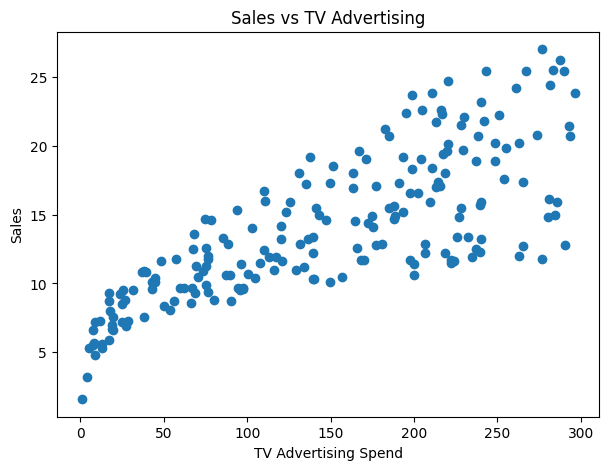

In [1132]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["TV Ad Budget ($)"],
    df["Sales ($)"]
)

plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs TV Advertising")

plt.show()

We can observe that Sales generally increase as TV advertising spending increases.

This indicates a **positive relationship** between TV advertising and Sales.

### Sales vs Radio

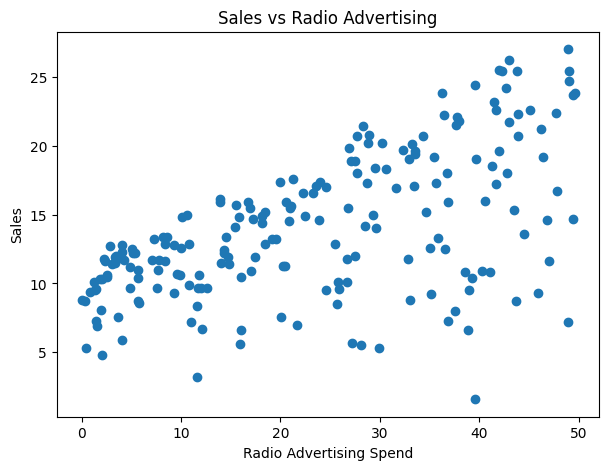

In [1133]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Radio Ad Budget ($)"],
    df["Sales ($)"]
)

plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs Radio Advertising")

plt.show()

Radio also shows a positive relationship with Sales, although it is weaker than TV.

### Sales vs Newspaper

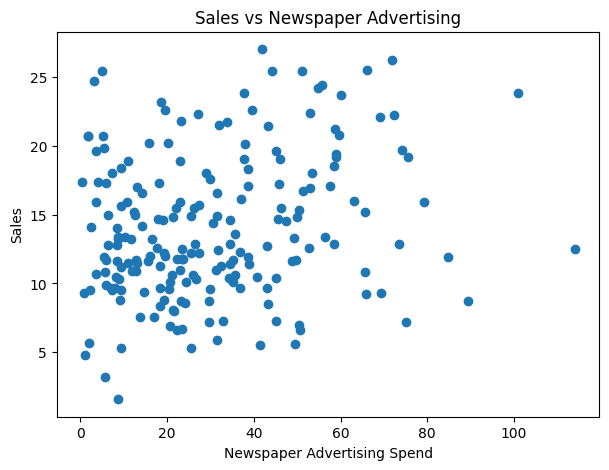

In [1134]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Newspaper Ad Budget ($)"],
    df["Sales ($)"]
)

plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")
plt.title("Sales vs Newspaper Advertising")

plt.show()

The relationship between Newspaper advertising and Sales appears weaker than TV and Radio.

### Pairplot

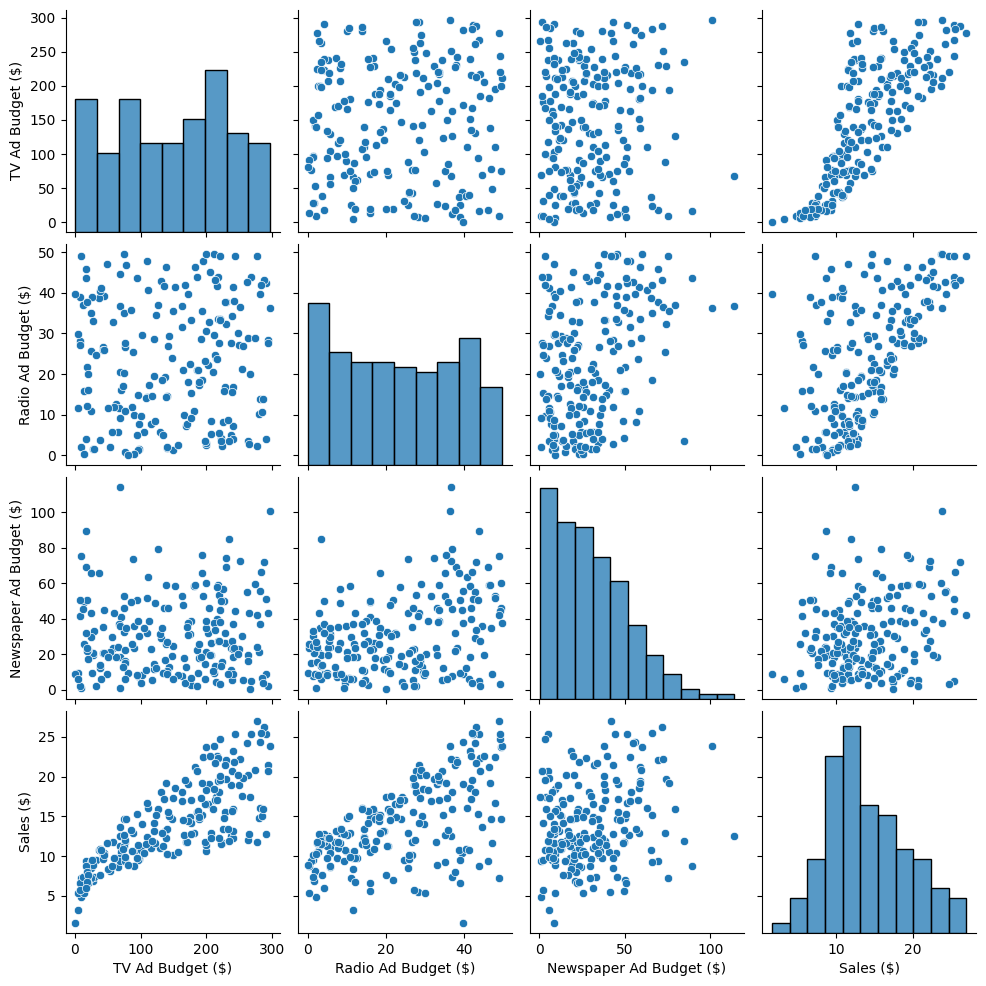

In [1135]:
sns.pairplot(df)
plt.show()

We can observe that:

* TV ↔ Sales has a relatively strong positive relationship.

* Radio ↔ Sales also has a positive relationship.

* Newspaper ↔ Sales appears considerably weaker.

### Correlation Matrix

In [1136]:
correlation = df.corr()

correlation

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
TV Ad Budget ($),1.000000,0.054809,0.056648,0.782224
Radio Ad Budget ($),0.054809,1.000000,0.354104,0.576223
Newspaper Ad Budget ($),0.056648,0.354104,1.000000,0.228299
Sales ($),0.782224,0.576223,0.228299,1.000000


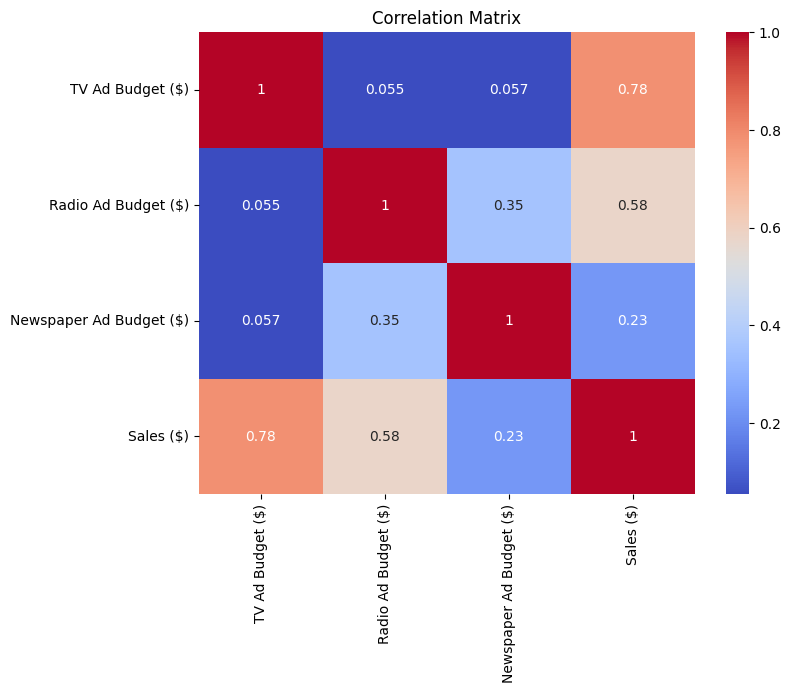

In [1137]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

**TV has the strongest correlation with Sales.**

In [1138]:
X = df[
    [
        "TV Ad Budget ($)",
        "Radio Ad Budget ($)",
        "Newspaper Ad Budget ($)"
    ]
]

In [1139]:
y = df["Sales ($)"]

In [1140]:
X

,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($)
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [1141]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: Sales ($), Length: 200, dtype: float64

### Train-test split

In [1142]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (160, 3)
X_test : (40, 3)
y_train: (160,)
y_test : (40,)


### Train Linear Regression

In [1143]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Get the Linear Regression Equation

In [1144]:
print("Coefficients:")
print(lr.coef_)

print("Intercept:")
print(lr.intercept_)

Coefficients:
[0.04472952 0.18919505 0.00276111]
Intercept:
2.979067338122629


### Make Predictions

In [1145]:
y_pred_lr = lr.predict(X_test)
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_lr
})

comparison.head(10)


,Actual Sales,Predicted Sales
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


### Evaluate Linear Regression 
**MAE**

In [1146]:
mae_lr = mean_absolute_error(
    y_test,
    y_pred_lr
)

print("MAE:", mae_lr)

MAE: 1.4607567168117603


The model's predictions are off by approximately **1.46 Sales units on average.**

Lower MAE is better.

**RMSE**

In [1147]:
rmse_lr = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_lr
    )
)

print("RMSE:", rmse_lr)

RMSE: 1.78159966153345


Lower RMSE is better.

**R² Score**

In [1148]:
r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print("R² Score:", r2_lr)

R² Score: 0.899438024100912


In [1149]:
print("-------------------------")
print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_lr)
print("RMSE:", rmse_lr)
print("R²  :", r2_lr)

-------------------------
Linear Regression Results
-------------------------
MAE : 1.4607567168117603
RMSE: 1.78159966153345
R²  : 0.899438024100912


### Train an Additional Model
**Random Forest Regressor**

In [1150]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Random Forest Predictions

In [1151]:
y_pred_rf = rf.predict(X_test)

### Evaluate Random Forest
**MAE**

In [1152]:

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

**RMSE**

In [1153]:
rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

**R² score**

In [1154]:
r2_rf = r2_score(
    y_test,
    y_pred_rf
)

In [1155]:
print("Random Forest Results")
print("---------------------")

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 0.6200999999999988
RMSE: 0.7685910811348248
R²  : 0.9812843792541843


### Compare Both Models

In [1156]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    
    "MAE": [
        mae_lr,
        mae_rf
    ],
    
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    
    "R2 Score": [
        r2_lr,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


### Residual Plot for Best Model

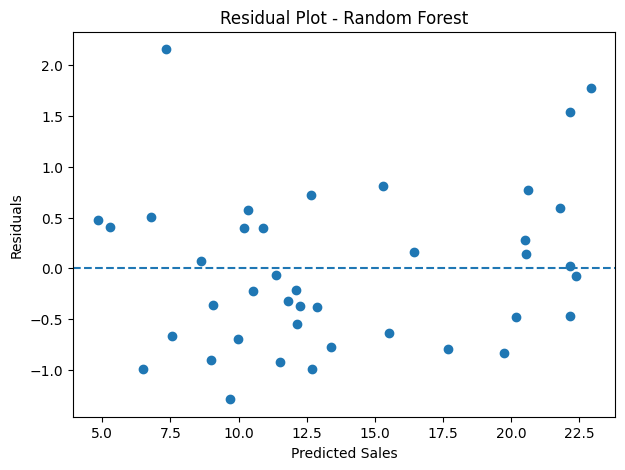

In [1157]:
residuals = y_test - y_pred_rf
plt.figure(figsize=(7,5))

plt.scatter(
    y_pred_rf,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.show()

### Find Which Advertising Channel Has Highest Impact
We can use **Random Forest feature** importance.

In [1158]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TV Ad Budget ($),0.624810
1,Radio Ad Budget ($),0.362201
2,Newspaper Ad Budget ($),0.012989


So according to the Random Forest model:

**TV advertising has the highest predictive importance.**

### Plot Feature Importance

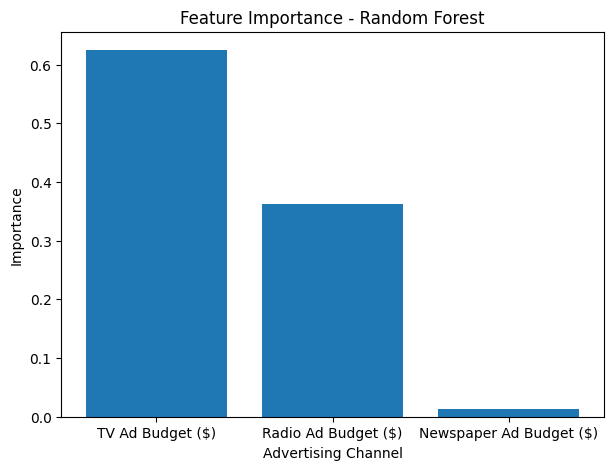

In [1159]:
plt.figure(figsize=(7,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Advertising Channel")
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")

plt.show()

## Interpretation

The analysis shows that TV advertising has the strongest relationship with Sales among the three advertising channels. The correlation between TV advertising and Sales is approximately 0.78.

The Random Forest model also identifies TV as the most important feature, followed by Radio and Newspaper.

However, feature importance and correlation indicate predictive relationships and should not be interpreted as proof that advertising spending directly causes sales to increase.


## Conclusion

In this project, a Sales Prediction system was developed using advertising expenditure on TV, Radio, and Newspaper.

Exploratory Data Analysis was performed using descriptive statistics, scatter plots, a pairplot, and a correlation heatmap.

Linear Regression was trained as the baseline model and evaluated using MAE, RMSE, and R² score. Random Forest Regression was then trained as an additional model.

Based on the test results, Random Forest performed better than Linear Regression, achieving lower MAE and RMSE and a higher R² score.

Feature importance analysis showed that TV advertising had the highest predictive importance, followed by Radio and Newspaper.